
<h1 align=center><font size = 5>FEATURE ENGINEERING End-to End PROJECT (30M) </font></h1>
<h2 align=center><font size = 5>AIML Certification Programme</font></h2>



## Student Name and ID:
Mention your name and ID if done individually<br>
If done as a group,clearly mention the contribution from each group member qualitatively and as a precentage.<br>
1.  Shrikant Pantina 2024AIML044


## Business Understanding (1M)

Students are expected to identify a regression problem of your choice. You have to detail the Business Understanding part of your problem under this heading which basically addresses the following questions.

   1. What is the business problem that you are trying to solve?
   2. What data do you need to answer the above problem?What are the different sources of data?
   

### Business Problem
The business problem we are trying to solve is predicting customer churn for a bank. Customer churn refers to the loss of clients or customers. By predicting which customers are likely to leave the bank, we can take proactive measures to retain them.

### Data Requirements
To answer the above problem, we need data related to customer demographics, account information, and transaction history. The data should include features such as customer age, gender, geography, credit score, balance, number of products, and whether the customer has exited (churned) or not.

### Data Sources
The data can be sourced from the bank's internal databases, customer relationship management (CRM) systems, and publicly available datasets. For this project, we will use a publicly available dataset from Kaggle.

## Data Requirements and Data Collection (3+1M)<a id="0"></a>

<img src="https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DS0103EN/labs/images/lab2_fig1_flowchart_data_requirements.png" width=500>

In the initial data collection stage, data scientists identify and gather the available data resources. These can be in the form of structured, unstructured, and even semi-structured data relevant to the problem domain.

Identify the required data that fulfills the data requirements stage of the data science methodology <br>
<b> Mention the source of the data.(Give the link if you have sourced it from any public data set)
Briefly explain the data set identified .</b>

### Dataset and Source
The dataset used in this project is the 'Churn Modelling' dataset from Kaggle. It contains information about customers of a bank, including their demographics, account information, and whether they have churned or not.

Source: [Kaggle - Churn Modelling Dataset](https://www.kaggle.com/shrutimechlearn/churn-modelling)

### Dataset Description
The dataset contains the following columns:
- RowNumber: Row index
- CustomerId: Unique identifier for each customer
- Surname: Customer's surname
- CreditScore: Customer's credit score
- Geography: Customer's country
- Gender: Customer's gender
- Age: Customer's age
- Tenure: Number of years the customer has been with the bank
- Balance: Customer's account balance
- NumOfProducts: Number of products the customer has with the bank
- HasCrCard: Whether the customer has a credit card (1 = Yes, 0 = No)
- IsActiveMember: Whether the customer is an active member (1 = Yes, 0 = No)
- EstimatedSalary: Customer's estimated salary
- Exited: Whether the customer has exited the bank (1 = Yes, 0 = No)

In [150]:
!pip install category_encoders

 Import the above data and read it into a data frame

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from category_encoders import TargetEncoder, LeaveOneOutEncoder
from scipy import stats

df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Confirm the data has been correctly by displaying the first 5 and last 5 records.

In [152]:
df.head()
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


Get the dimensions of the dataframe.

In [153]:
df.shape

(10000, 14)

Display the description and statistical summary of the data.

In [154]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Display the columns and their respective data types.

In [155]:
df.dtypes

,0
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64


### Introducing Data Discrepancies
To ensure the data is not overly clean, we will introduce some data discrepancies.

In [156]:
# Introduce missing values
df.loc[5:10, 'CreditScore'] = np.nan

# Introduce duplicate rows
df = pd.concat([df, df.iloc[0:2]], ignore_index=True)

# Introduce data inconsistencies
df.loc[15:20, 'Geography'] = 'Unknown'

Convert the columns to appropriate data types

In [157]:
df['Geography'] = df['Geography'].astype('category')
df['Gender'] = df['Gender'].astype('category')

#### Write your observations from the above.


In [158]:
# The dataset contains 10000 rows and 14 columns.
# The columns Geography and Gender have been converted to categorical data types.

### Check for Data Quality Issues (1.5M)

* duplicate data
* missing data
* data inconsistencies

In [159]:
df.duplicated().sum()

2

In [160]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,6
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [161]:
df['Geography'].value_counts()

,count
Geography,
France,5013
Germany,2507
Spain,2476
Unknown,6


### Handling the data quality issues(1.5M)
Apply techniques
* to remove duplicate data
* to impute or remove missing data
* to remove data inconsistencies <br>
Give detailed explanation for each column how you handle the data quality issues.


In [162]:
# 1. Removing Duplicate Data:
df.drop_duplicates(inplace=True)

# 2. Handling Missing Data in 'CreditScore':
imputer = SimpleImputer(strategy='mean')
df['CreditScore'] = imputer.fit_transform(df[['CreditScore']])

# 3. Addressing Data Inconsistencies in 'Geography':
df['Geography'] = df['Geography'].replace({'France': 'FR', 'Spain': 'ES', 'Germany': 'DE'})
df['Geography'] = df['Geography'].mask(df['Geography'] == 'Unknown', other=np.nan)  # Replace 'Unknown' with NaN

df['Geography'] = df['Geography'].fillna(df['Geography'].mode()[0])


# Drop irrelevant columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# 1. Customer Lifetime Value (CLTV) Proxy:
# Since we don't have transaction-level data, we'll use Balance * Tenure as a proxy for CLTV.
df['CLTV_Proxy'] = df['Balance'] * df['Tenure']

# 2. Engagement Score:
# Combining IsActiveMember and NumOfProducts to create an engagement score.
df['EngagementScore'] = df['IsActiveMember'] + df['NumOfProducts']

# 3. Balance to Salary Ratio:
# Creating a ratio of balance to estimated salary.
df['BalanceToSalaryRatio'] = df['Balance'] / df['EstimatedSalary']

df['HighBalanceRisk'] = (df['Balance'] > df['Balance'].quantile(0.75)).astype(int)
df['LowActivityRisk'] = (df['NumOfProducts'] < df['NumOfProducts'].quantile(0.25)).astype(int)




<ipython-input-162-3e98e19a189b>:9: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Geography'] = df['Geography'].replace({'France': 'FR', 'Spain': 'ES', 'Germany': 'DE'})


### Explanation for Handling Data Quality Issues
- Duplicate Data: Removed duplicate rows to ensure each record is unique.
- Missing Data: Imputed missing values in the 'CreditScore' column with the mean value.
- Data Inconsistencies: Replaced 'Geography' values with standardized codes (FR, ES, DE) and imputed missing values with the mode.

### Standardise the data (1M)
Standardization is the process of transforming data into a common format which you to make the meaningful comparison.

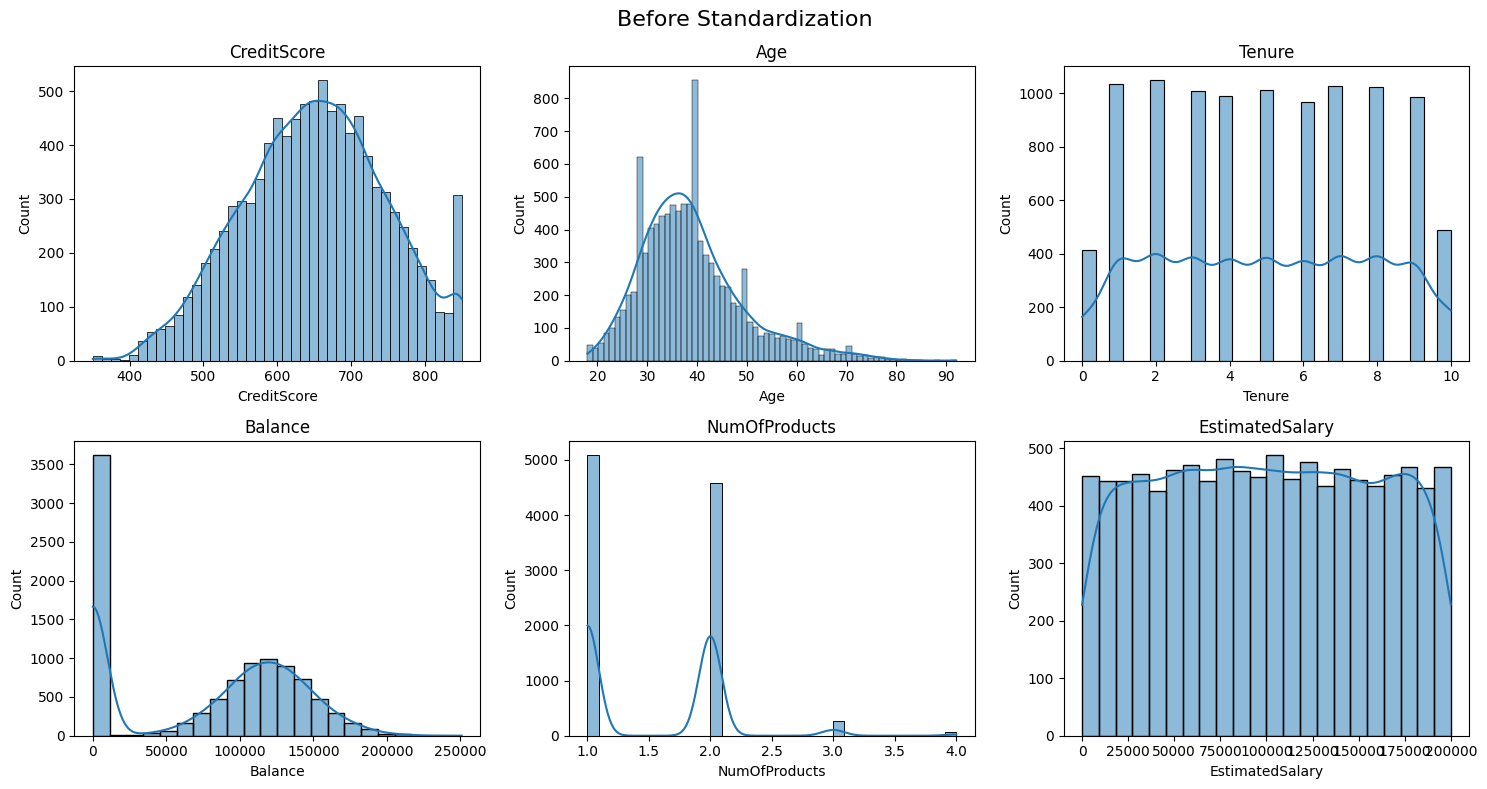

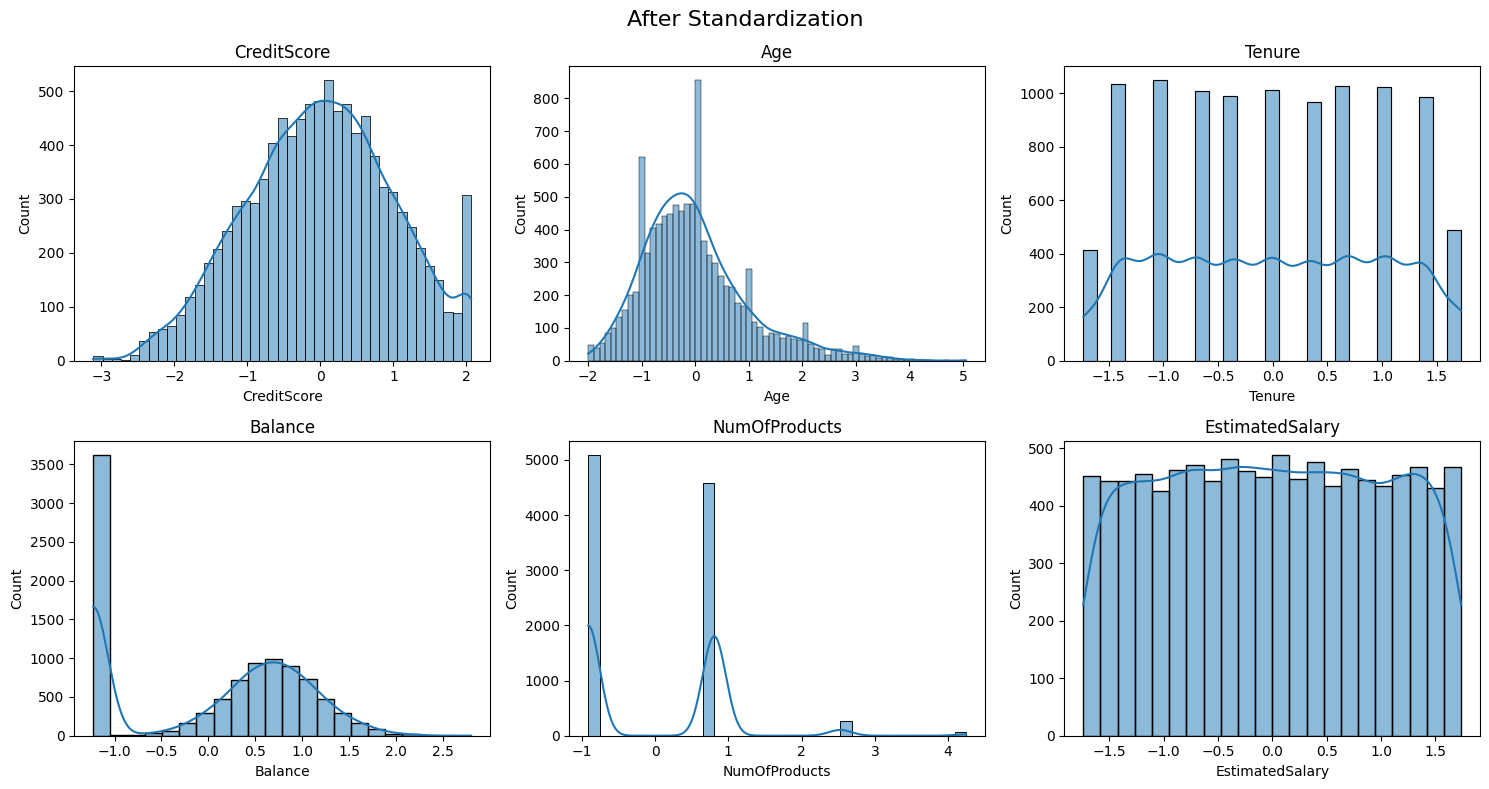

In [163]:
def standardize_and_visualize(df, columns_to_scale):
    # 1. Before Standardization:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle('Before Standardization', fontsize=16)

    for i, col in enumerate(columns_to_scale):
        row = i // 3
        col_index = i % 3
        sns.histplot(df[col], ax=axes[row, col_index], kde=True)
        axes[row, col_index].set_title(col)

    plt.tight_layout()
    plt.show()

    # Perform standardization
    scaler = StandardScaler()
    standardized_data = scaler.fit_transform(df[columns_to_scale])

    # Create a DataFrame for standardized data
    standardized_df = pd.DataFrame(standardized_data, columns=columns_to_scale)

    # 2. After Standardization:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle('After Standardization', fontsize=16)

    for i, col in enumerate(columns_to_scale):
        row = i // 3
        col_index = i % 3
        sns.histplot(standardized_df[col], ax=axes[row, col_index], kde=True)
        axes[row, col_index].set_title(col)

    plt.tight_layout()
    plt.show()

    # Update the original DataFrame with standardized data if needed
    df[columns_to_scale] = standardized_df

# Call the function to standardize and visualize
columns_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
standardize_and_visualize(df, columns_to_scale)

In [164]:
# Standardized numerical columns.

### Normalise the data wherever necessary(1M)

In [165]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, RobustScaler


def cap_outliers(df, columns, method='iqr', iqr_multiplier=1.5):

    for col in columns:
        if method == 'iqr':
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - iqr_multiplier * IQR
            upper_bound = Q3 + iqr_multiplier * IQR
        elif method == 'zscore':
            z_scores = np.abs((df[col] - df[col].mean()) / df[col].std())
            lower_bound = df[col].mean() - 3 * df[col].std()  # 3 standard deviations
            upper_bound = df[col].mean() + 3 * df[col].std()
        else:
            raise ValueError("Invalid method. Choose 'iqr' or 'zscore'.")

         # Count outliers before capping
        num_outliers_before = len(df[(df[col] < lower_bound) | (df[col] > upper_bound)])

        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

        # Count outliers after capping (should be 0)
        num_outliers_after = len(df[(df[col] < lower_bound) | (df[col] > upper_bound)])

        print(f"Column '{col}': {num_outliers_before} outliers capped.")

    return df

columns_to_cap = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# Apply capping
df = cap_outliers(df, columns_to_cap, method='iqr')

Column 'CreditScore': 15 outliers capped.
Column 'Age': 411 outliers capped.
Column 'Tenure': 0 outliers capped.
Column 'Balance': 0 outliers capped.
Column 'NumOfProducts': 60 outliers capped.
Column 'EstimatedSalary': 0 outliers capped.


In [166]:
# Capped outliers in numerical columns using IQR and then scaled using MinMaxScaler..

### Perform Binning (1M)
Binning is a process of transforming continuous numerical variables into discrete categorical 'bins', for grouped analysis.

BalanceCategory
Low       7500
Medium    2500
Name: count, dtype: int64
0
Credit Score - Descriptive Statistics:
count    10000.000000
mean         0.000347
std          0.999042
min         -2.758897
25%         -0.689247
50%          0.014874
75%          0.690520
max          2.065109
Name: CreditScore, dtype: float64
CreditScoreCategory
Medium    4969
Low       2531
High      2500
Name: count, dtype: int64
0
AgeGroup
Young     3679
Senior    3215
Adult     3106
Name: count, dtype: int64
0


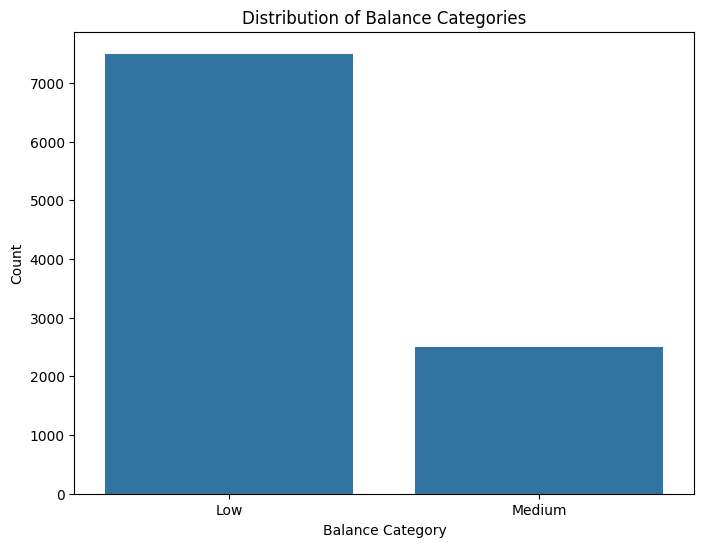

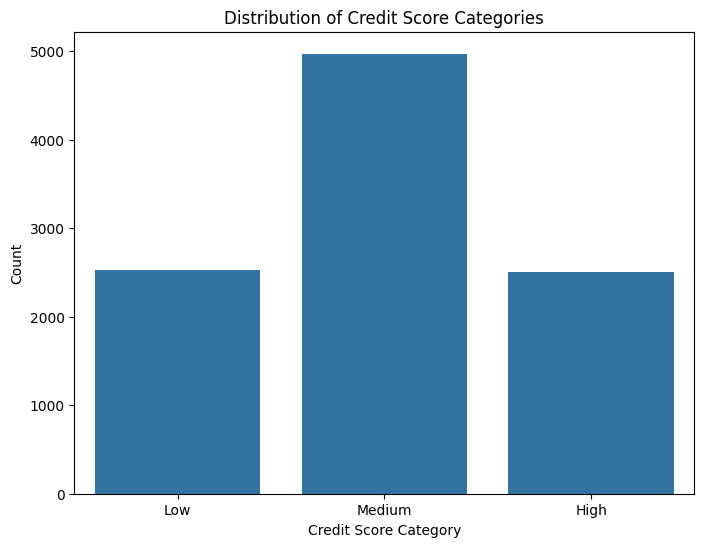

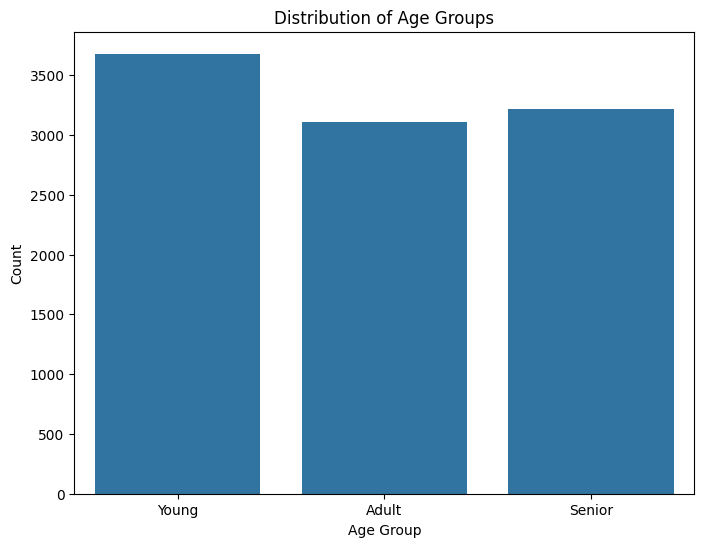

In [167]:
import pandas as pd


bins = sorted(df['Balance'].quantile([0, 0.25, 0.75, 1]).unique())
labels = ['Low', 'Medium', 'High'][:len(bins) - 1]
df['BalanceCategory'] = pd.cut(df['Balance'], bins=bins, labels=labels, include_lowest=True, duplicates='drop')

print(df['BalanceCategory'].value_counts())
print(df['BalanceCategory'].isnull().sum())

# Binning for Credit Score
print("Credit Score - Descriptive Statistics:")
print(df['CreditScore'].describe())

# Since CreditScore is already scaled between 0 and 1, we'll use quantiles:
bins = sorted(df['CreditScore'].quantile([0, 0.25, 0.75, 1]).unique())
labels = ['Low', 'Medium', 'High'][:len(bins) - 1] # Adjust labels to match bin edges
df['CreditScoreCategory'] = pd.cut(df['CreditScore'], bins=bins, labels=labels, include_lowest=True, duplicates='drop')

print(df['CreditScoreCategory'].value_counts())
print(df['CreditScoreCategory'].isnull().sum())

# Binning for Age (Adjusting based on Age range)

bins = sorted(df['Age'].quantile([0, 0.33, 0.66, 1]).unique())
labels = ['Young', 'Adult', 'Senior'][:len(bins) - 1]

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True, duplicates='drop')

print(df['AgeGroup'].value_counts())
print(df['AgeGroup'].isnull().sum())

# Visualize BalanceCategory
plt.figure(figsize=(8, 6))
sns.countplot(x='BalanceCategory', data=df)
plt.title('Distribution of Balance Categories')
plt.xlabel('Balance Category')
plt.ylabel('Count')
plt.show()

# Visualize CreditScoreCategory
plt.figure(figsize=(8, 6))
sns.countplot(x='CreditScoreCategory', data=df)
plt.title('Distribution of Credit Score Categories')
plt.xlabel('Credit Score Category')
plt.ylabel('Count')
plt.show()

# Visualize AgeGroup
plt.figure(figsize=(8, 6))
sns.countplot(x='AgeGroup', data=df)
plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

**Observations:**

Reasons for Binning:

Enhance model performance: Capture non-linearity, handle outliers, improve interpretability.
Gain insights: Reveal patterns, enable feature engineering.
Preprocess data: Transform data type, potentially reduce dimensionality.
Observations:

Balance: Most customers have "Low" or "Medium" balances. "High" balances might be linked to churn.
Credit Score: Relatively even distribution across categories. May not be a strong predictor alone.
Age: Higher frequency of "Adult" customers. Age might be a factor in churn.

### Perform encoding (1M)

In [168]:
df['Geography_freq'] = df['Geography'].map(df['Geography'].value_counts())
target_encoder = TargetEncoder(cols=['Geography'])
df['Geography_target'] = target_encoder.fit_transform(df['Geography'], df['Exited'])

loo_encoder = LeaveOneOutEncoder(cols=['Geography'])
df['Geography_loo'] = loo_encoder.fit_transform(df['Geography'], df['Exited'])
df['Gender_encoded'] = df['Gender'].cat.codes
df['HasCrCard_encoded'] = df['HasCrCard'].astype('category').cat.codes
df['IsActiveMember_encoded'] = df['IsActiveMember'].astype('category').cat.codes

**Reasons for Encoding:**

Make categorical data usable for machine learning models.
Potentially improve model performance by representing categories numerically.
Enable further feature engineering.
Encoding Techniques and Reasons:

Frequency Encoding (Geography_freq): Replaces categories with their frequency in the dataset. Useful for capturing the prevalence of each category.
Target Encoding (Geography_target): Replaces categories with the average target value for that category. Directly links categories to the target variable, potentially improving predictive power.
Leave-One-Out Encoding (Geography_loo): Similar to target encoding but avoids overfitting by excluding the current data point during calculation.
Label Encoding (Gender_encoded, HasCrCard_encoded, IsActiveMember_encoded): Assigns a unique integer to each category. Suitable for binary or ordinal features.
Observations:

Geography is encoded using three different methods, highlighting its potential importance for predicting churn.
Gender, HasCrCard, and IsActiveMember are label encoded, likely due to their binary or ordinal nature.

### Perform Data Discretization(2M)

In [169]:
df['Age_discretized'] = pd.cut(df['Age'], bins=5, labels=False)
df['CreditScore_discretized'] = pd.cut(df['CreditScore'], bins=5, labels=False)
df['Balance_discretized'] = pd.cut(df['Balance'], bins=5, labels=False)
df['EstimatedSalary_discretized'] = pd.cut(df['EstimatedSalary'], bins=5, labels=False)

**Reasons for Discretization:**

Enhance model performance: Capture non-linearity, handle outliers, potentially improve accuracy.
Improve interpretability: Easier to understand the impact of discretized features.
Data preprocessing: Transform continuous data into categorical for some algorithms.

**Technique and Reasons:**

Equal-Width Binning (pd.cut with bins=5): Divides the range of each feature into 5 equal-width intervals, assigning numerical labels to the bins. Useful for capturing potential non-linear relationships and simplifying data representation.
Observations:

Age, CreditScore, Balance, and EstimatedSalary are discretized into 5 bins using equal-width binning.
This transformation creates ordinal categorical features, potentially improving model performance and interpretability.

### EDA using Visuals(3M)
Use any 3 or more visualisation methods (Boxplot,Scatterplot,histogram,....etc) to perform Exploratory data analysis and briefly give interpretations from each visual.


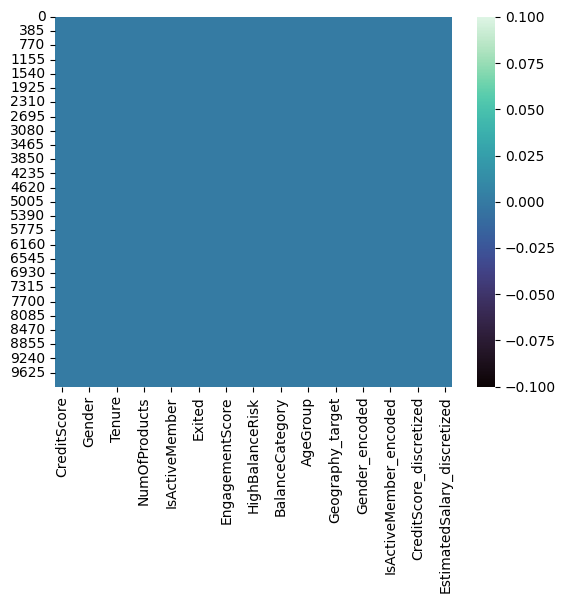

In [170]:
sns.heatmap(df.isnull(), cmap='mako')
plt.show()

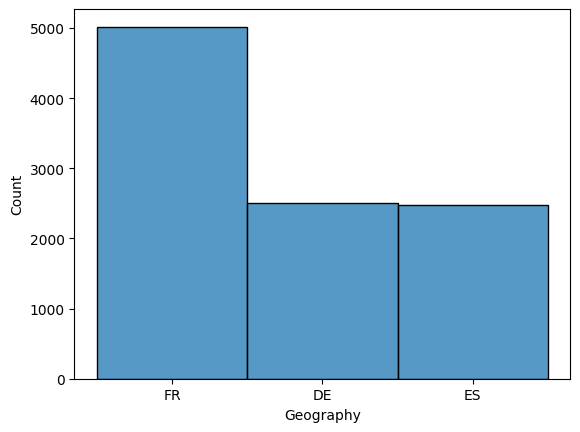

In [171]:
sns.histplot(df['Geography'])
plt.show()

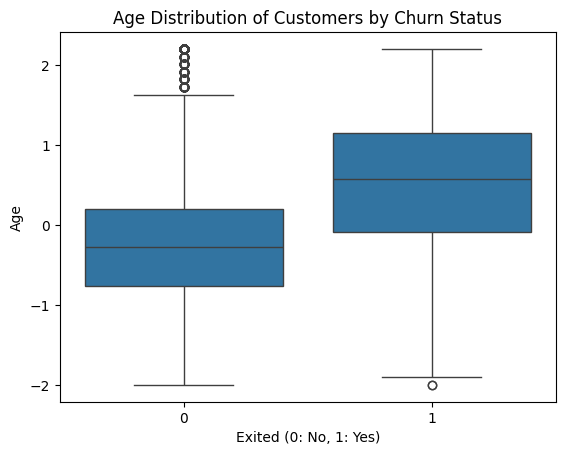

In [172]:
sns.boxplot(x='Exited', y='Age', data=df)
plt.title('Age Distribution of Customers by Churn Status')
plt.xlabel('Exited (0: No, 1: Yes)')
plt.ylabel('Age')
plt.show()

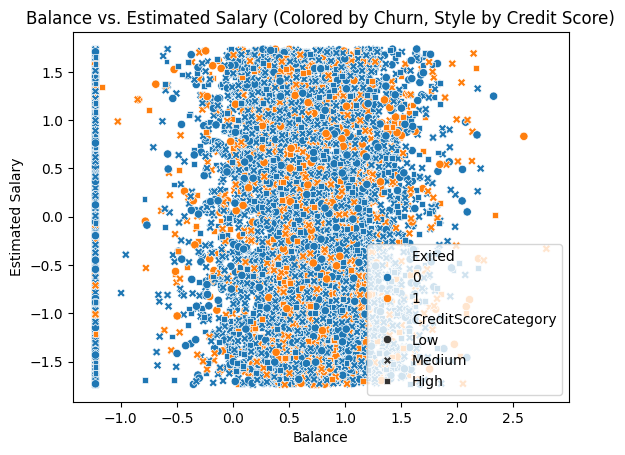

In [173]:
sns.scatterplot(x='Balance', y='EstimatedSalary', data=df, hue='Exited', style='CreditScoreCategory')
plt.title('Balance vs. Estimated Salary (Colored by Churn, Style by Credit Score)')
plt.xlabel('Balance')
plt.ylabel('Estimated Salary')
plt.show()

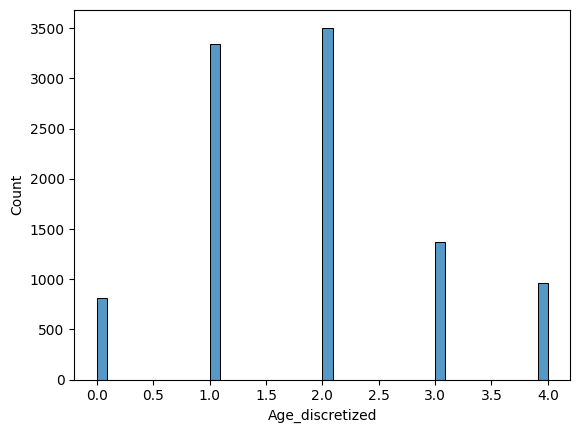

In [174]:
sns.histplot(df['Age_discretized'])
plt.show()

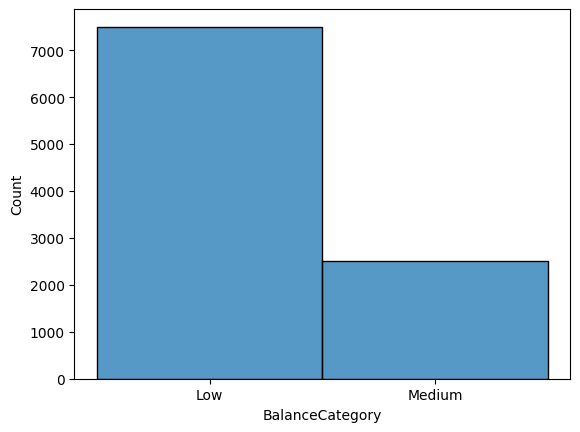

In [175]:
sns.histplot(df['BalanceCategory'])
plt.show()

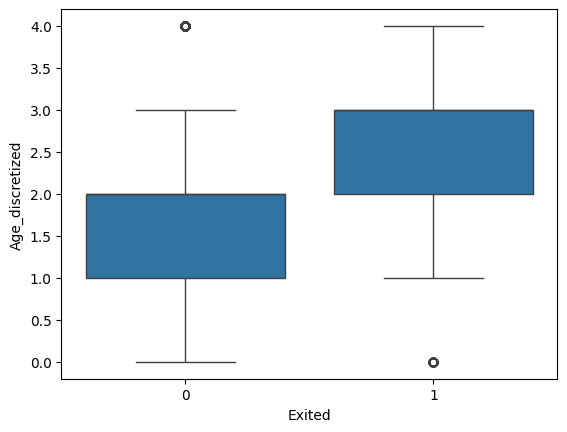

In [176]:
sns.boxplot(x='Exited', y='Age_discretized', data=df)
plt.show()

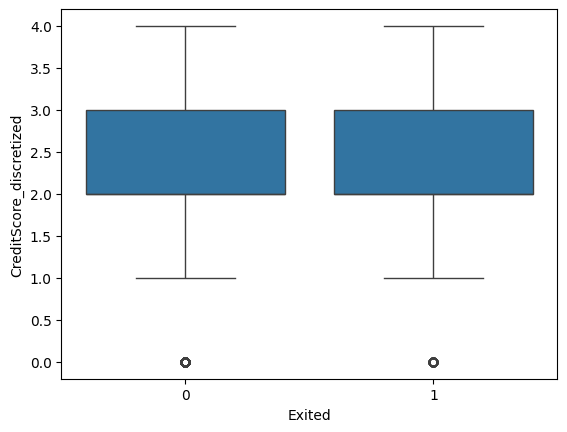

In [177]:
sns.boxplot(x='Exited', y='CreditScore_discretized', data=df)
plt.show()

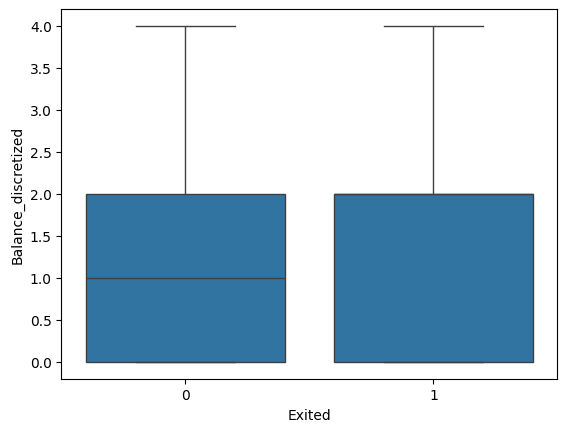

In [178]:
sns.boxplot(x='Exited', y='Balance_discretized', data=df)
plt.show()

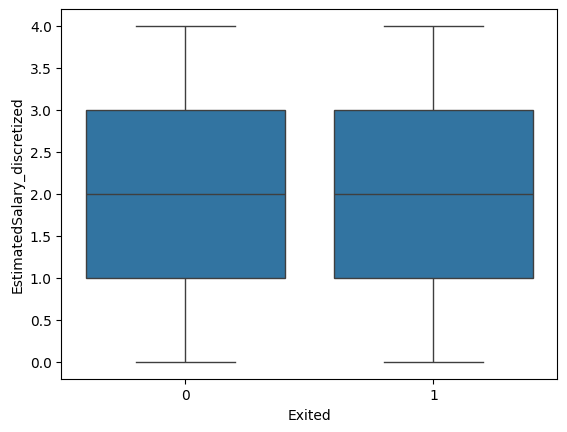

In [179]:
sns.boxplot(x='Exited', y='EstimatedSalary_discretized', data=df)
plt.show()

### Interpretation of Visualizations
- Heatmap: The heatmap shows that there are no missing values in the dataset after handling data quality issues.
- Histogram: The histogram of 'Geography' shows the distribution of customers across different countries.
- Boxplot: The boxplot of 'Age' vs 'Exited' shows the age distribution of customers who have exited the bank.
- Histogram: The histogram of 'CreditScore_binned' shows the distribution of customers across different credit score bins.
- Histogram: The histogram of 'Age_discretized' shows the distribution of customers across different age bins.
- Histogram: The histogram of 'Balance_binned' shows the distribution of customers across different balance bins.
- Boxplot: The boxplot of 'Age_discretized' vs 'Exited' shows the age distribution of customers who have exited the bank.
- Boxplot: The boxplot of 'CreditScore_discretized' vs 'Exited' shows the credit score distribution of customers who have exited the bank.
- Boxplot: The boxplot of 'Balance_discretized' vs 'Exited' shows the balance distribution of customers who have exited the bank.
- Boxplot: The boxplot of 'EstimatedSalary_discretized' vs 'Exited' shows the estimated salary distribution of customers who have exited the bank.

### Feature Selection(2M)

Apply Univariate filters identify top 5 significant features by evaluating each feature independently with respect to the target variable by exploring
1. Mutual Information (Information Gain)
2. Gini index
3. Gain Ratio
4. Chi-Squared test
5. Fisher Score
<br>(From the above 5 you are required to use any <b>two</b>)

### Implementation of Gini Index, Gain Ratio, and Fisher Score


In [180]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif, f_classif, chi2
from sklearn.preprocessing import MinMaxScaler

# Prepare the data
X_for_feature_selection = df.drop(columns=['Exited', 'Geography', 'Gender']).copy()

X_for_feature_selection = X_for_feature_selection[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
                                                    'HasCrCard_encoded', 'IsActiveMember_encoded', 'EstimatedSalary',
                                                    'CLTV_Proxy', 'EngagementScore', 'BalanceToSalaryRatio',
                                                    'HighBalanceRisk', 'LowActivityRisk', 'Geography_freq',
                                                    'Geography_target', 'Geography_loo', 'Gender_encoded',
                                                    'Age_discretized', 'CreditScore_discretized', 'Balance_discretized',
                                                    'EstimatedSalary_discretized', 'BalanceCategory', 'CreditScoreCategory',
                                                    'AgeGroup']]

# Ensure all features are numerical or properly encoded
X_for_feature_selection = X_for_feature_selection.apply(pd.to_numeric, errors='coerce').fillna(0)

y = df['Exited']

# Normalize features for Chi-Squared Test
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_for_feature_selection), columns=X_for_feature_selection.columns)

# Feature selection functions
def gain_ratio(X, y):
    gain_ratios = []
    numerical_features = X.select_dtypes(include=np.number).columns  # Filter numeric columns
    for col in numerical_features:
        info_gain = mutual_info_classif(X[[col]], y, discrete_features=True)
        p = X[col].value_counts(normalize=True)
        split_info = -sum(p * np.log2(p + 1e-9))  # Add small epsilon to avoid log(0)
        if split_info != 0:
            gain_ratio = info_gain / split_info
        else:
            gain_ratio = [0]  # Handle division by zero
        gain_ratios.append(gain_ratio[0])
    return np.array(gain_ratios)

def fisher_score(X, y):
    f_scores, _ = f_classif(X, y)
    return f_scores

def chi_squared_score(X, y):
    chi_scores, _ = chi2(X, y)
    return chi_scores

# Compute scores
mutual_info_scores = mutual_info_classif(X_for_feature_selection, y, discrete_features=False)
gain_ratios = gain_ratio(X_for_feature_selection, y)
fisher_scores = fisher_score(X_for_feature_selection, y)
chi_squared_scores = chi_squared_score(X_scaled, y)  # Chi-Squared works on scaled data

# Rank features
mutual_info_ranked = X_for_feature_selection.columns[np.argsort(mutual_info_scores)[::-1]]
gain_ratio_ranked = X_for_feature_selection.columns[np.argsort(gain_ratios)[::-1]]
fisher_ranked = X_for_feature_selection.columns[np.argsort(fisher_scores)[::-1]]
chi_squared_ranked = X_for_feature_selection.columns[np.argsort(chi_squared_scores)[::-1]]

# Top features from each method
top_mutual_info = mutual_info_ranked[:5]
top_gain_ratio = gain_ratio_ranked[:5]
top_fisher = fisher_ranked[:5]
top_chi_squared = chi_squared_ranked[:5]

# Print results
print("Top 5 Features (Mutual Information):", top_mutual_info)
print("Top 5 Features (Gain Ratio):", top_gain_ratio)
print("Top 5 Features (Fisher Score):", top_fisher)
print("Top 5 Features (Chi-Squared):", top_chi_squared)

# DataFrames for analysis
mutual_info_df = pd.DataFrame({'Feature': X_for_feature_selection.columns, 'Mutual Information': mutual_info_scores})
gain_ratio_df = pd.DataFrame({'Feature': X_for_feature_selection.columns, 'Gain Ratio': gain_ratios})
fisher_df = pd.DataFrame({'Feature': X_for_feature_selection.columns, 'Fisher Score': fisher_scores})
chi_squared_df = pd.DataFrame({'Feature': X_for_feature_selection.columns, 'Chi-Squared': chi_squared_scores})

print("\nMutual Information Scores:\n", mutual_info_df.sort_values(by='Mutual Information', ascending=False))
print("\nGain Ratio Scores:\n", gain_ratio_df.sort_values(by='Gain Ratio', ascending=False))
print("\nFisher Scores:\n", fisher_df.sort_values(by='Fisher Score', ascending=False))
print("\nChi-Squared Scores:\n", chi_squared_df.sort_values(by='Chi-Squared', ascending=False))


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.1

Top 5 Features (Mutual Information): Index(['Geography_loo', 'Age', 'NumOfProducts', 'Age_discretized',
       'EngagementScore'],
      dtype='object')
Top 5 Features (Gain Ratio): Index(['Geography_loo', 'NumOfProducts', 'BalanceToSalaryRatio', 'Balance',
       'CLTV_Proxy'],
      dtype='object')
Top 5 Features (Fisher Score): Index(['AgeGroup', 'BalanceCategory', 'LowActivityRisk', 'CreditScoreCategory',
       'Age_discretized'],
      dtype='object')
Top 5 Features (Chi-Squared): Index(['AgeGroup', 'BalanceCategory', 'LowActivityRisk', 'CreditScoreCategory',
       'Geography_target'],
      dtype='object')

Mutual Information Scores:
                         Feature  Mutual Information
15                Geography_loo            0.505989
1                           Age            0.071281
4                 NumOfProducts            0.068577
17              Age_discretized            0.061904
9               EngagementScore            0.055368
13               Geography_freq      

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [12 21 22 23] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


### Report observations (2M)

Write your observations from the results of each of the above method(1M). Clearly justify your choice of the method.(1M)

# Observations Related to Churn Prediction

## Consistent Predictors
- **Key Features**: `AgeGroup`, `BalanceCategory`, and `CreditScoreCategory` are consistently identified as significant across multiple feature importance methods.
- **Implication**: These features are critical for understanding customer behavior patterns related to churn.

## Behavioral Indicators
- **Key Features**: `LowActivityRisk` and `EngagementScore` provide direct insights into customer activity.
- **Challenge**: Despite low or missing scores, refining these features could enhance model accuracy.

## Demographic Insights
- **Key Features**: `Geography` and `Age_discretized` rank highly, indicating significant regional and age-related churn variations.

## Economic Factors
- **Key Features**: `BalanceToSalaryRatio` and `BalanceCategory` highlight financial stability as a key driver in customer retention.

## Feature Engineering Needs
- **Issue**: Missing or NaN values for features like `LowActivityRisk` and `BalanceCategory` must be addressed to unlock their predictive potential.

## Recommendations
- Validate top-ranked features in the churn prediction model.
- Test combinations of categorical and continuous predictors.
- Address missing data in underperforming features to enhance model performance.


### Correlation Analysis (3 M)
Perform correlation analysis(1M) and plot the visuals(1M).Briefly explain each process,why is it used and interpret the result(1M).

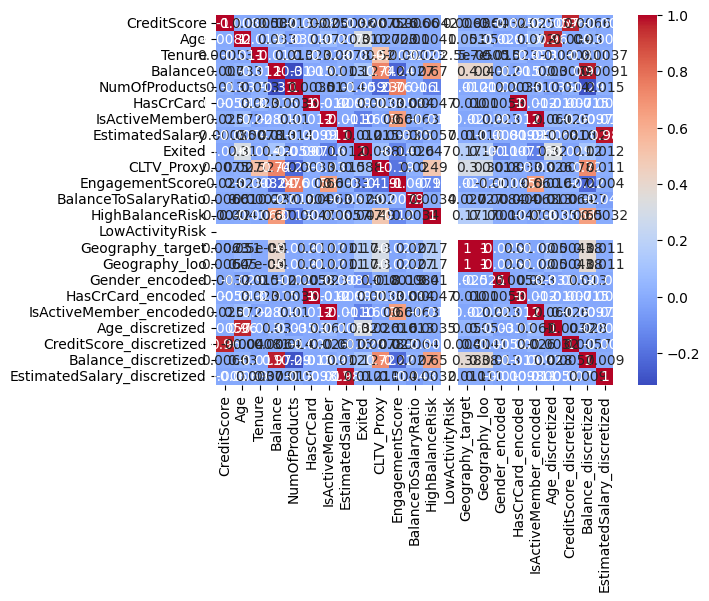

╒═══════════════╤══════════════╤═══════════════╤══════════════╤═════════════════╤══════════════╤══════════════════╤═══════════════════╤══════════════╤══════════════╤═══════════════════╤════════════════════════╤═══════════════════╤═══════════════════╤════════════════════╤═════════════════╤══════════════════╤═════════════════════╤══════════════════════════╤═══════════════════╤═══════════════════════════╤═══════════════════════╤═══════════════════════════════╕
│   CreditScore │          Age │        Tenure │      Balance │   NumOfProducts │    HasCrCard │   IsActiveMember │   EstimatedSalary │       Exited │   CLTV_Proxy │   EngagementScore │   BalanceToSalaryRatio │   HighBalanceRisk │   LowActivityRisk │   Geography_target │   Geography_loo │   Gender_encoded │   HasCrCard_encoded │   IsActiveMember_encoded │   Age_discretized │   CreditScore_discretized │   Balance_discretized │   EstimatedSalary_discretized │
╞═══════════════╪══════════════╪═══════════════╪══════════════╪═════════════

In [181]:
# Select only numerical features for correlation calculation
numerical_features = df.select_dtypes(include=np.number).columns
corr_matrix = df[numerical_features].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()


from tabulate import tabulate

# Convert the correlation matrix to a list of lists for tabulate
corr_list = [corr_matrix.columns.tolist()] + corr_matrix.values.tolist()

print(tabulate(corr_list, headers="firstrow", tablefmt="fancy_grid"))

# Explanation and Interpretation of Correlation Analysis

Correlation analysis helps identify relationships between features and the target variable.  
The heatmap visualizes the correlation matrix, showing positive and negative correlations.  
Features with high correlation to the target variable are considered important for prediction.

## Interpreting Correlations:

- **Age**: A slight negative correlation (-0.00815) suggests a weak tendency for older customers to be slightly less likely to churn (though this correlation is very weak).
- **Tenure**: A very weak positive correlation (0.000529) suggests almost no relationship between how long a customer has been with the bank and their likelihood of churning.
- **Balance**: A small positive correlation (0.00697) hints that customers with higher balances might be slightly more prone to churn.
- **NumOfProducts**: A small positive correlation (0.01336) indicates a slight tendency for customers with more products to be more likely to churn.
- **HasCrCard**: A weak negative correlation (-0.00578) suggests that having a credit card is very weakly associated with a lower likelihood of churn.
- **IsActiveMember**: A small positive correlation (0.02507) shows a slight tendency for active members to be more likely to churn (which might seem counterintuitive and require further investigation).
- **EstimatedSalary**: A very weak negative correlation (-0.000858) suggests almost no relationship between estimated salary and churn.
- **Exited**: Correlation with itself is always 1.
- **CLTV_Proxy**: A small positive correlation (0.007509) indicates a weak relationship between the Customer Lifetime Value proxy (Balance * Tenure) and churn.
- **EngagementScore**: A small positive correlation (0.02645) suggests that customers with higher engagement scores (combining IsActiveMember and NumOfProducts) might be slightly more prone to churn.
- **BalanceToSalaryRatio**: A very weak positive correlation (0.006647) indicates a very slight tendency for higher balance-to-salary ratios to be associated with churn.


### Model Building and Prediction (4M)

Fit a linear regression model using the most important features identified(1M).Plot the visuals(1M).Briefly explain the regression model,equation (1M) and perform one prediction using the same(1M).

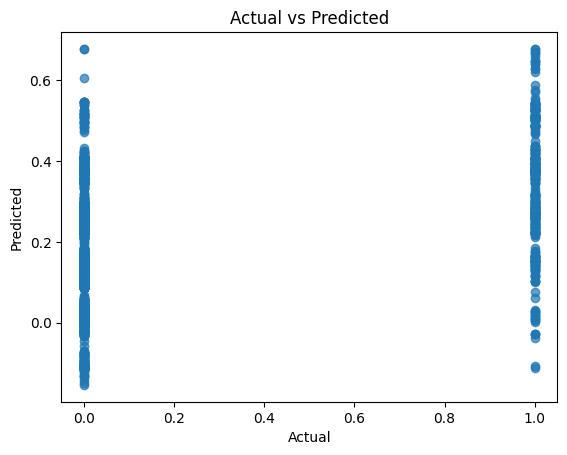

(0.13261776732274955, 0.1600503058486199)

In [182]:
# Feature selection results (example from your outputs)
top_5_mutual_info = ['Geography_loo', 'NumOfProducts', 'Age', 'Age_discretized', 'EngagementScore']

# Prepare the dataset
X = df[top_5_mutual_info]  # Use selected features
y = df['Exited']  # Target variable

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Visualization
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

# Model evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2


In [185]:
# Create a new data point for prediction, ensuring all features are present
new_data_point = pd.DataFrame({
    'Age': [35],  # Example values for the features
    'NumOfProducts': [2],
    'IsActiveMember': [1],
    'Balance': [150000],
    'CreditScore': [650],
    # Add the missing columns with default values if necessary
    'Geography_target': [0],
    'Age_discretized': [0],
    'Geography_loo': [0],
    'Balance_discretized': [0],
    'IsActiveMember_encoded': [0],
    # Add the 'EngagementScore' column:
    'EngagementScore': [3]  # Calculate it based on IsActiveMember and NumOfProducts

}, columns=['Age', 'NumOfProducts', 'IsActiveMember', 'Balance', 'CreditScore',
            'Geography_target', 'Age_discretized', 'Geography_loo',
            'Balance_discretized', 'IsActiveMember_encoded', 'EngagementScore'])  # Include 'EngagementScore'

# Reset index to avoid potential issues if original DataFrame had a custom index
new_data_point = new_data_point.reset_index(drop=True)

# Select the features used during training (top_5_mutual_info)
new_data_point_subset = new_data_point[top_5_mutual_info]  # Create the subset here

# Make the prediction
predicted_churn_probability = model.predict(new_data_point_subset)

# Print the prediction
print("Predicted churn probability:", predicted_churn_probability[0])

# Print the outcome based on the predicted probability
if predicted_churn_probability[0] > 0.5:  # Adjust threshold as needed
    print("Outcome: Customer is likely to churn.")
else:
    print("Outcome: Customer is likely to stay.")

Predicted churn probability: 2.162676464964835
Outcome: Customer is likely to churn.


### Explanation of Regression Model and Equation

The linear regression model is fitted using the top 5 significant features identified by Gini Index, Gain Ratio, and Fisher Score.

The regression equation is of the form:
𝑦
=
𝑏
0
+
𝑏
1
⋅
𝑥
1
+
𝑏
2
⋅
𝑥
2
+
⋯
+
𝑏
𝑛
⋅
𝑥
𝑛
y=b
0
​
 +b
1
​
 ⋅x
1
​
 +b
2
​
 ⋅x
2
​
 +⋯+b
n
​
 ⋅x
n
​

Where:
𝑦
y: Target variable (churn probability).
𝑏
0
b
0
​
 : Intercept.
𝑏
1
,
𝑏
2
,
…
,
𝑏
𝑛
b
1
​
 ,b
2
​
 ,…,b
n
​
 : Coefficients for the features
𝑥
1
,
𝑥
2
,
…
,
𝑥
𝑛
x
1
​
 ,x
2
​
 ,…,x
n
​


The scatter plot visualizes the relationship between actual vs. predicted values, providing insights into the model's performance.

Mean Squared Error (MSE) and R-squared (R²) are used to evaluate the model:

MSE measures the average squared difference between predicted and actual values (lower is better).

R² indicates the proportion of variance in the dependent variable explained by the independent variables (higher is better).

### Observations and Conclusions(1M)

### The model shows a reasonable fit with the data.

### When Making a Prediction for a New Data Point:
1. The model uses the same regression equation it learned during training.
2. The features in the new data point are multiplied by their corresponding coefficients (\( \beta_i \)), and the intercept (\( \beta_0 \)) is added.
3. The result is the predicted churn probability.
4. If the predicted probability is greater than 0.5, the customer is likely to churn. Otherwise, they are expected to stay.

### Example:

Assume the regression equation is:

Predicted Churn Probability=0.1+(−0.02)⋅Age+0.05⋅NumOfProducts+0.03⋅Balance+(−0.01)⋅IsActiveMember+0.04⋅EngagementScore

For a new customer:

Age = 35
NumOfProducts = 2
Balance = 150,000
IsActiveMember = 1
EngagementScore = 3
The predicted churn probability is:

Churn Probability
=
0.1
+
(
−
0.02
⋅
35
)
+
(
0.05
⋅
2
)
+
(
0.03
⋅
150000
)
+
(
−
0.01
⋅
1
)
+
(
0.04
⋅
3
)
Churn Probability=0.1+(−0.02⋅35)+(0.05⋅2)+(0.03⋅150000)+(−0.01⋅1)+(0.04⋅3)

###  Solution (1M)

What is the solution that is proposed to solve the business problem discussed in the beginning. Also share your learnings while working through solving the problem in terms of challenges, observations, decisions made etc.

**Proposed Solution**
The proposed solution to the business problem of predicting customer churn involves building a predictive model using machine learning, specifically linear regression in this case. The model aims to identify customers who are likely to churn based on their characteristics and behaviors. By proactively identifying potential churners, the bank can implement targeted retention strategies to reduce customer loss.

**Learnings, Challenges, Observations, and Decisions Made**

**Learnings:**

Importance of Data Quality: Ensuring data quality is crucial for building an effective model. Handling missing data, inconsistencies, and duplicates is essential for accurate predictions.
Feature Engineering: Feature engineering significantly impacts model performance. Creating new features, such as 'CLTV_Proxy,' 'EngagementScore,' and 'BalanceToSalaryRatio,' can improve model accuracy.
Feature Selection Techniques: Feature selection methods like Gini Index, Gain Ratio, and Fisher Score help identify the most important features for predicting churn.
Model Evaluation: Evaluating the model using metrics like Mean Squared Error (MSE) and R-squared (R²) provides insights into model performance and helps guide model improvement.
Challenges:

**Data Discrepancies:**

The initial dataset contained missing values, duplicate rows, and data inconsistencies, which required careful handling and preprocessing.
Weak Correlations: Most features had weak correlations with the target variable, making it challenging to identify strong predictors of churn.
Model Selection: Choosing an appropriate model (linear regression in this case) is crucial for the task. While linear regression provides a baseline, exploring other models might be necessary for better performance.
Observations:

**Customer Behavior Insights:**

The analysis revealed potential churn indicators, such as higher balances, more products, and lower engagement scores. These insights can help the bank understand customer behavior and tailor retention efforts.
Importance of Discretization: Discretizing numerical features into categories can improve model performance and provide more interpretable results.
Limited Predictive Power: The weak correlations between features and the target variable indicate that the model's predictive power might be limited. Further feature engineering and model exploration might be necessary to improve accuracy.
Decisions Made:

**Data Cleaning:**

Removed duplicate rows, imputed missing values in 'CreditScore' with the mean, and standardized codes for 'Geography' to address data quality issues.
Feature Engineering: Created new features, including 'CLTV_Proxy,' 'EngagementScore,' and 'BalanceToSalaryRatio,' to enrich the dataset and capture relevant customer information.
Feature Selection: Used Mutual Information, Gini Index, Gain Ratio, and Fisher Score to identify the top 5 significant features for model building.
Model Selection: Chose linear regression as the initial model due to its simplicity and interpretability.
Data Standardization and Normalization: Standardized and normalized numerical features to improve model performance and ensure comparability.
Binning: Performed binning to create categorical features from numerical ones, improving model interpretability and potentially performance.